# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [52]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [2]:
import warnings
warnings.filterwarnings('ignore')

### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [3]:
# Add as many cells as you need

df = pd.read_csv("zillow_clean.csv")

print(df.shape)
df.head()

(71808, 33)


,airconditioningtypeid,basementsqft,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fireplacecnt,fullbathcnt,...,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,taxdelinquencyflag,censustractandblock,taxvaluedollarcnt
0,0.0,0.0,3.5,4.0,8.0,3.5,3100.0,3100.0,0.0,3.0,...,96978.0,0.0,1.0,1.0,1998.0,1.0,2016.0,0,6.059063e+13,1023282.0
1,0.0,0.0,1.0,2.0,8.0,1.0,1465.0,1465.0,1.0,1.0,...,97099.0,5.0,0.0,1.0,1967.0,1.0,2016.0,0,6.111001e+13,464000.0
2,0.0,0.0,2.0,3.0,8.0,2.0,1243.0,1243.0,0.0,2.0,...,97078.0,6.0,0.0,1.0,1962.0,1.0,2016.0,0,6.059022e+13,564778.0
3,0.0,0.0,3.0,4.0,8.0,3.0,2376.0,2376.0,0.0,3.0,...,96330.0,0.0,0.0,1.0,1970.0,1.0,2016.0,0,6.037300e+13,145143.0
4,1.0,0.0,3.0,3.0,8.0,3.0,1312.0,1312.0,0.0,3.0,...,96451.0,0.0,0.0,1.0,1964.0,1.0,2016.0,0,6.037124e+13,119407.0


In [4]:
# remove top 1% outliers on target variable 

threshold = df['taxvaluedollarcnt'].quantile(0.97)
df = df[df['taxvaluedollarcnt'] <= threshold]

print(df.shape)

(69653, 33)


In [5]:
df['taxvaluedollarcnt'].max()

np.float64(1654764.0)

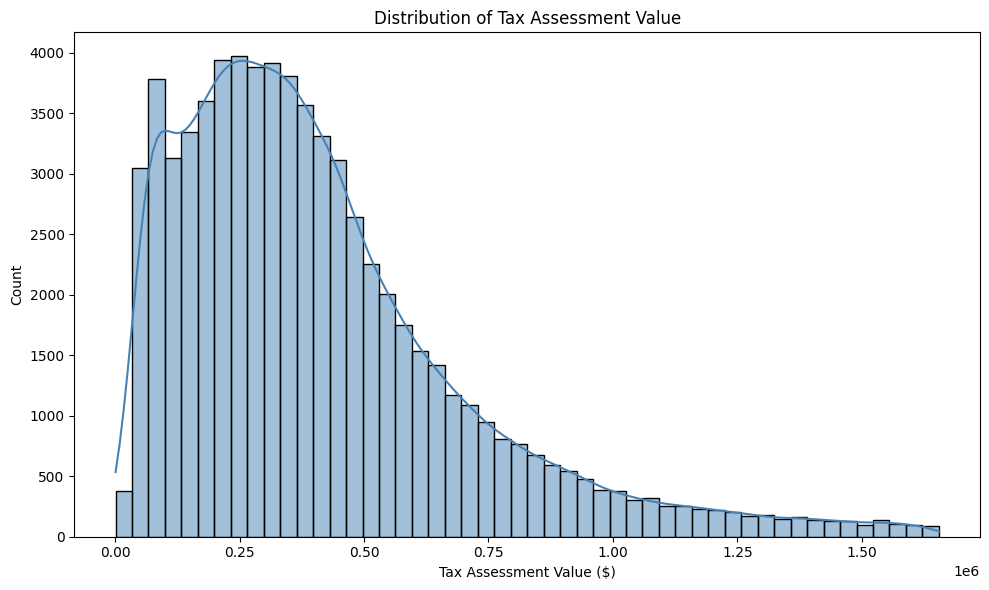

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df['taxvaluedollarcnt'],
    # np.log1p(df['taxvaluedollarcnt']),
    bins=50,
    kde=True,
    color='steelblue'
)
plt.title('Distribution of Tax Assessment Value')
plt.xlabel('Tax Assessment Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
X = df.drop(columns=['taxvaluedollarcnt'])  
X = X.select_dtypes(include='number')
y = df['taxvaluedollarcnt']   

# --------- Train-Test Split -----------
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, train_size=0.8, shuffle=True)

# Before splitting
print('Full feature set:', X.shape)

# After splitting
print('Training feature set:', X_train.shape)
print('Testing feature set:', X_test.shape)

print('-------------------------------')

# Before splitting
print('Full target set:', y.shape)

# After splitting
print('Training target set:', y_train.shape)
print('Testing target set:', y_test.shape)


Full feature set: (69653, 32)
Training feature set: (55722, 32)
Testing feature set: (13931, 32)
-------------------------------
Full target set: (69653,)
Training target set: (55722,)
Testing target set: (13931,)


In [8]:
# Standard Scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees (HistGradient Boosting)

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [33]:
# ---------------------------------------
# ------------ Random Forest ------------
# ------------- Base Model --------------
# ---------------------------------------


rfreg = RandomForestRegressor(bootstrap=True, oob_score=True, random_state=random_state, n_jobs=-1)
rfreg.fit(X_train_scaled,y_train)

neg_mae_scores = cross_val_score(rfreg, X_train_scaled, y_train, 
    scoring='neg_mean_absolute_error',  
    cv=5,
    n_jobs=-1
)

mean_cv_mae = -np.mean(neg_mae_scores)  
std_cv_mae = np.std(-neg_mae_scores)
oob_score = rfreg.oob_score_

features = pd.DataFrame(
    data= list(zip(X.columns, rfreg.feature_importances_)),
    columns=['features', 'importances']
).sort_values('importances', ascending=False)


# Print the results
print(f'Average MAE CV: {mean_cv_mae}')
print(f'Std Dev of MAE CV: {std_cv_mae}')
print(f'OOB Score: {oob_score}')
print('Feature Importance:')
features



Average MAE CV: 148818.5631188562
Std Dev of MAE CV: 1018.5092030421117
OOB Score: 0.5105157977526092
Feature Importance:


,features,importances
6,calculatedfinishedsquarefeet,0.184094
7,finishedsquarefeet12,0.183951
14,latitude,0.115347
15,longitude,0.088891
27,yearbuilt,0.077382
16,lotsizesquarefeet,0.067287
23,regionidzip,0.065196
31,censustractandblock,0.043056
4,buildingqualitytypeid,0.032220
20,regionidcity,0.020920


In [34]:
# Add as many cells as you need

# ---------------------------------------
# ------------ Random Forest ------------
# ---------------------------------------

# Wrapper function to simplify experiments with RF models

def run_random_forest_regressor(X_train_scaled, y_train, 
                                # n_estimators = 150,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                # max_features = 18,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                # ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    rf_model = RandomForestRegressor(
        # n_estimators = n_estimators,
        # max_depth = max_depth,
        # max_samples = max_samples,
        # min_samples_split = min_samples_split,
        # min_samples_leaf = min_samples_leaf,
        # max_features = max_features,
        # max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = -1,             
        random_state = random_state,
        oob_score = True
        # ccp_alpha=ccp_alpha,
    )
    
    # Perform cross-validation
    neg_mae_scores = cross_val_score(
        rf_model, X_train_scaled, y_train, 
        scoring='neg_mean_absolute_error',  # 'neg_root_mean_squared_error',
        cv=cv,
        n_jobs=n_jobs
    )

    mean_cv_mae = -np.mean(neg_mae_scores)  

    rf_model.fit(X_train_scaled, y_train)

    # Feature Importance 
    features = pd.DataFrame(
        data= list(zip(X.columns, rf_model.feature_importances_)),
        columns=['features', 'importances']
    ).sort_values('importances', ascending=False)

    oob_score = rf_model.oob_score_

    
    return {
    'avg_cv_mae': mean_cv_mae,
    'cv_std': np.std(-neg_mae_scores),
    'oob_score': oob_score,
    'features importance': features
    }
    

In [35]:
run_random_forest_regressor(X_train_scaled, y_train)
                                # , max_depth = None         
                                # , min_samples_split = 2    
                                # , min_samples_leaf = 1     
                                # , max_samples = None      
                                # , max_leaf_nodes=None
                                # , max_features = None         
                               # )


{'avg_cv_mae': np.float64(148818.5631188562),
 'cv_std': np.float64(1018.5092030421117),
 'oob_score': 0.5105157977526092,
 'features importance':                         features  importances
 6   calculatedfinishedsquarefeet     0.184094
 7           finishedsquarefeet12     0.183951
 14                      latitude     0.115347
 15                     longitude     0.088891
 27                     yearbuilt     0.077382
 16             lotsizesquarefeet     0.067287
 23                   regionidzip     0.065196
 31           censustractandblock     0.043056
 4          buildingqualitytypeid     0.032220
 20                  regionidcity     0.020920
 22          regionidneighborhood     0.017881
 5              calculatedbathnbr     0.016477
 11               garagetotalsqft     0.013933
 3                     bedroomcnt     0.013498
 2                    bathroomcnt     0.013317
 18     propertycountylandusecode     0.008130
 17                       poolcnt     0.006259
 0      

In [26]:
# RF Base model - parameters set to default

# run_random_forest_regressor(X_train_scaled, y_train, 
#                                 n_estimators = 150,       
#                                 max_depth = None,         
#                                 min_samples_split = 2,    
#                                 min_samples_leaf = 1,     
#                                 max_samples = None,       
#                                 max_leaf_nodes=None,
#                                 max_features = 18,             
#                                 # ccp_alpha=0.0,
#                                )


{'avg_cv_mae': np.float64(148516.19146018726),
 'cv_std': np.float64(863.1939868082094),
 'oob_score': 0.5173507383329318,
 'features importance':                         features  importances
 6   calculatedfinishedsquarefeet     0.179529
 7           finishedsquarefeet12     0.171703
 14                      latitude     0.111243
 15                     longitude     0.082763
 27                     yearbuilt     0.073280
 23                   regionidzip     0.066371
 16             lotsizesquarefeet     0.062044
 31           censustractandblock     0.033755
 4          buildingqualitytypeid     0.032408
 2                    bathroomcnt     0.030233
 5              calculatedbathnbr     0.029811
 20                  regionidcity     0.023611
 22          regionidneighborhood     0.019689
 3                     bedroomcnt     0.013908
 11               garagetotalsqft     0.013352
 18     propertycountylandusecode     0.010075
 9                    fullbathcnt     0.006782
 17     

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

> Your text here

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [36]:
# Add as many cells as you need

def func_propage(df_home):
    df_home['propage'] = df_home['assessmentyear'] - df_home['yearbuilt']

def func_log(df_home, col):
    df_home[f"{col}_log"] = np.log1p(df_home[col])

def func_ratio(df_home, col, col1, col2):
    df_home[col] = df_home[col1] / df_home[col2]

In [37]:
# make a copy of the dateset

df_clean = df.copy()

In [73]:
func_propage(df_clean)

func_log(df_clean, 'calculatedfinishedsquarefeet')

func_ratio(df_clean, 'livingarearatio', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet')

df_clean['roomdensity'] = df_clean['roomcnt'] / (df_clean['calculatedfinishedsquarefeet'] + 1)

df_clean['bed_bath_interaction'] = df_clean['bedroomcnt'] * df_clean['bathroomcnt']

df_clean['bath_per_bed'] = df_clean['bathroomcnt'] / (df_clean['bedroomcnt'] + 1)

df_clean['bedroom_intensity'] = df_clean['bedroomcnt'] / (df_clean['calculatedfinishedsquarefeet'] + 1)

# ----------------------------------------
df_clean[['propage', 'livingarearatio', 'calculatedfinishedsquarefeet_log', 'roomdensity', 'bed_bath_interaction'
          , 'bath_per_bed','bedroom_intensity']].sample(8)

,propage,livingarearatio,calculatedfinishedsquarefeet_log,roomdensity,bed_bath_interaction,bath_per_bed,bedroom_intensity
41346,35.0,0.020349,7.707512,0.000000,15.0,0.500000,0.002247
62649,13.0,0.426745,8.051341,0.003187,15.0,0.500000,0.001593
57295,9.0,0.191322,7.237059,0.003597,7.5,0.625000,0.002158
2625,52.0,0.184747,7.131699,0.000000,8.0,0.400000,0.003197
55235,29.0,0.004334,6.816736,0.000000,4.0,0.666667,0.002191
7556,51.0,0.389778,7.470224,0.003989,10.0,0.500000,0.002279
37640,64.0,0.332559,7.448916,0.000000,8.0,0.400000,0.002328
25424,68.0,0.199277,7.055313,0.000000,4.0,0.666667,0.001726


In [79]:
new_features = ['propage', 'livingarearatio', 'calculatedfinishedsquarefeet_log', 'roomdensity', 'bed_bath_interaction'
                ,'bath_per_bed','bedroom_intensity']

X_new = df_clean[new_features]
y = df_clean['taxvaluedollarcnt']

f_stats, p_values = f_regression(X_new, y)

results = pd.DataFrame({
    'feature': new_features,
    'f_score': f_stats,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print(results)

                            feature       f_score       p_value
2  calculatedfinishedsquarefeet_log  27021.323696  0.000000e+00
4              bed_bath_interaction  17006.508568  0.000000e+00
6                 bedroom_intensity  11518.077367  0.000000e+00
5                      bath_per_bed   7274.306257  0.000000e+00
0                           propage   3019.731748  0.000000e+00
1                   livingarearatio   2879.757795  0.000000e+00
3                       roomdensity    157.418141  4.537747e-36


In [42]:
# drop assessment year

df_clean = df_clean.drop(columns=['assessmentyear'])

In [80]:
# Train / Test Split

X = df_clean.drop(columns=['taxvaluedollarcnt'])  
X = X.select_dtypes(include='number')
y = df_clean['taxvaluedollarcnt']   

# --------- Train-Test Split -----------
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, train_size=0.8, shuffle=True)

# Before splitting
print('Full feature set:', X.shape)

# After splitting
print('Training feature set:', X_train.shape)
print('Testing feature set:', X_test.shape)

print('-------------------------------')

# Before splitting
print('Full target set:', y.shape)

# After splitting
print('Training target set:', y_train.shape)
print('Testing target set:', y_test.shape)


Full feature set: (69653, 38)
Training feature set: (55722, 38)
Testing feature set: (13931, 38)
-------------------------------
Full target set: (69653,)
Training target set: (55722,)
Testing target set: (13931,)


In [81]:
# Standard Scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [82]:
# ---------------------------------------
# ------------ Random Forest ------------
# --------- Feature Engineered ----------
# ---------------------------------------


rfreg = RandomForestRegressor(bootstrap=True, oob_score=True, random_state=random_state, n_jobs=-1)
rfreg.fit(X_train_scaled,y_train)

neg_mae_scores = cross_val_score(rfreg, X_train_scaled, y_train, 
    scoring='neg_mean_absolute_error',  
    cv=5,
    n_jobs=-1
)

mean_cv_mae = -np.mean(neg_mae_scores)  
std_cv_mae = np.std(-neg_mae_scores)
oob_score = rfreg.oob_score_

features = pd.DataFrame(
    data= list(zip(X.columns, rfreg.feature_importances_)),
    columns=['features', 'importances']
).sort_values('importances', ascending=False)


# Print the results
print(f'Average MAE CV: {mean_cv_mae}')
print(f'Std Dev of MAE CV: {std_cv_mae}')
print(f'OOB Score: {oob_score}')
print('Feature Importance:')
features



Average MAE CV: 149201.33842048404
Std Dev of MAE CV: 832.0650478698043
OOB Score: 0.5088953036203553
Feature Importance:


,features,importances
7,finishedsquarefeet12,0.128884
6,calculatedfinishedsquarefeet,0.109593
32,calculatedfinishedsquarefeet_log,0.108795
14,latitude,0.102610
15,longitude,0.076318
23,regionidzip,0.062948
37,bedroom_intensity,0.049596
33,livingarearatio,0.040181
16,lotsizesquarefeet,0.038729
30,censustractandblock,0.038407


In [ ]:
# ---------------------------------------
# ------------ Random Forest ------------
# ---------------------------------------

# Wrapper function to simplify experiments with RF models

def run_random_forest_regressor(X_train_scaled, y_train, 
                                n_estimators = 150,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 18,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = -1,             
        random_state = random_state,
        oob_score = True
        # ccp_alpha=ccp_alpha,
    )
    
    # Perform cross-validation
    neg_mae_scores = cross_val_score(
        rf_model, X_train_scaled, y_train, 
        scoring='neg_mean_absolute_error',  # 'neg_root_mean_squared_error',
        cv=cv,
        n_jobs=n_jobs
    )

    mean_cv_mae = -np.mean(neg_mae_scores)  

    rf_model.fit(X_train_scaled, y_train)

    # Feature Importance 
    features = pd.DataFrame(
        data= list(zip(X.columns, rf_model.feature_importances_)),
        columns=['features', 'importances']
    ).sort_values('importances', ascending=False)

    oob_score = rf_model.oob_score_

    
    return {
    'avg_cv_mae': mean_cv_mae,
    'cv_std': np.std(-neg_mae_scores),
    'oob_score': oob_score,
    'features importance': features
    }

### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




> Your text here

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [83]:
# Add as many cells as you need

# Random Forest Feature Importance

print('Feature Importance:')
features


Feature Importance:


,features,importances
7,finishedsquarefeet12,0.128884
6,calculatedfinishedsquarefeet,0.109593
32,calculatedfinishedsquarefeet_log,0.108795
14,latitude,0.102610
15,longitude,0.076318
23,regionidzip,0.062948
37,bedroom_intensity,0.049596
33,livingarearatio,0.040181
16,lotsizesquarefeet,0.038729
30,censustractandblock,0.038407


In [84]:
# SequentialFeatureSelector (SFS) is model-agnostic

# Ridge Pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

In [85]:
# Forward Feature Selection

feature_range = range(12, 27, 2)

results = []

for k in feature_range:
    sfs = SequentialFeatureSelector(
        ridge_pipeline,
        n_features_to_select=k,
        direction='forward',
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1
    )
    
    sfs.fit(X_train, y_train)
    
    selected = X_train.columns[sfs.get_support()]
    
    scores = cross_val_score(
        ridge_pipeline,
        X_train[selected],
        y_train,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1
    )
    
    mae = -scores.mean()
    results.append((k, mae))

print(results)

[(12, np.float64(169083.3915708513)), (14, np.float64(168854.0636565043)), (16, np.float64(168703.48963742165)), (18, np.float64(168629.08078841385)), (20, np.float64(168546.50491884415)), (22, np.float64(168492.6445913579)), (24, np.float64(168486.51407928808)), (26, np.float64(168486.36275779165))]


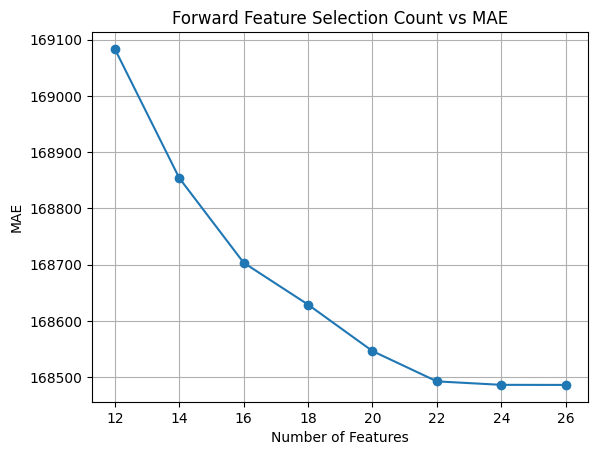

In [86]:
# Forward Plot

ks = [r[0] for r in results]
maes = [r[1] for r in results]

plt.plot(ks, maes, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.title('Forward Feature Selection Count vs MAE')
plt.grid(True)
plt.show()

In [87]:
# Forward Feature Selection

sfs = SequentialFeatureSelector(
    ridge_pipeline,
    direction='forward',
    n_features_to_select=22,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]

print('Forward feature selection:')
print(selected_features)

Forward feature selection:
Index(['bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet',
       'fireplacecnt', 'garagetotalsqft', 'hashottuborspa', 'latitude',
       'longitude', 'lotsizesquarefeet', 'poolcnt',
       'propertycountylandusecode', 'regionidcity', 'regionidcounty',
       'regionidneighborhood', 'roomcnt', 'threequarterbathnbr', 'unitcnt',
       'propage', 'calculatedfinishedsquarefeet_log', 'bed_bath_interaction',
       'bath_per_bed', 'bedroom_intensity'],
      dtype='object')


In [88]:
# Backward Feature Selection

feature_range = range(12, 27, 2)

results = []

for k in feature_range:
    sfs = SequentialFeatureSelector(
        ridge_pipeline,
        n_features_to_select=k,
        direction='backward',
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1
    )
    
    sfs.fit(X_train, y_train)
    
    selected = X_train.columns[sfs.get_support()]
    
    scores = cross_val_score(
        ridge_pipeline,
        X_train[selected],
        y_train,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1
    )
    
    mae = -scores.mean()
    results.append((k, mae))

print(results)

[(12, np.float64(168954.98514276926)), (14, np.float64(168774.97544816672)), (16, np.float64(168666.5256116338)), (18, np.float64(168580.6120231821)), (20, np.float64(168513.8844243511)), (22, np.float64(168486.59932608853)), (24, np.float64(168485.2693782933)), (26, np.float64(168485.26819178564))]


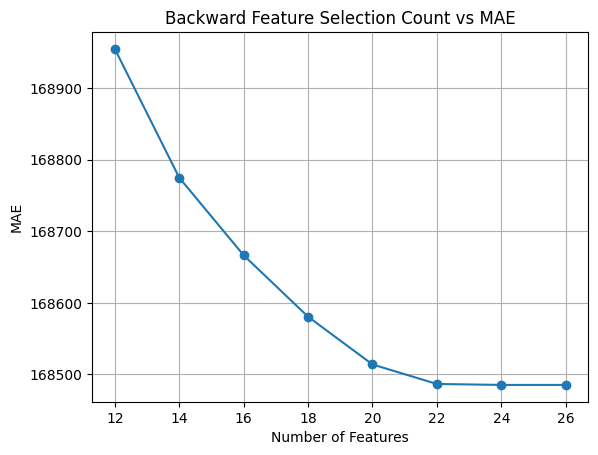

In [89]:
# Backward Plot

ks = [r[0] for r in results]
maes = [r[1] for r in results]

plt.plot(ks, maes, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.title('Backward Feature Selection Count vs MAE')
plt.grid(True)
plt.show()

In [90]:
# Backward Feature Selection

sfs = SequentialFeatureSelector(
    ridge_pipeline,
    direction='backward',
    n_features_to_select=22,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]

print('Backward feature selection:')
print(selected_features)

Backward feature selection:
Index(['bedroomcnt', 'buildingqualitytypeid', 'finishedsquarefeet12',
       'fireplacecnt', 'garagetotalsqft', 'hashottuborspa', 'latitude',
       'longitude', 'lotsizesquarefeet', 'poolcnt',
       'propertycountylandusecode', 'regionidcity', 'regionidcounty',
       'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr',
       'numberofstories', 'propage', 'calculatedfinishedsquarefeet_log',
       'bed_bath_interaction', 'bedroom_intensity'],
      dtype='object')


In [100]:
# Define selected features

features = ['finishedsquarefeet12','latitude','longitude','regionidzip','livingarearatio','lotsizesquarefeet','bedroom_intensity'
            ,'propage','buildingqualitytypeid','regionidcity','bath_per_bed','regionidneighborhood','bathroomcnt','garagetotalsqft'
            ,'bed_bath_interaction','roomdensity','propertycountylandusecode','bedroomcnt','poolcnt','fireplacecnt'
            ,'roomcnt','censustractandblock','garagecarcnt','hashottuborspa']

# Train / Test Split

X = df_clean[features]
X = X.select_dtypes(include='number')
y = df_clean['taxvaluedollarcnt']   

# --------- Train-Test Split -----------
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, train_size=0.8, shuffle=True)

# Before splitting
print('Full feature set:', X.shape)

# After splitting
print('Training feature set:', X_train.shape)
print('Testing feature set:', X_test.shape)

print('-------------------------------')

# Before splitting
print('Full target set:', y.shape)

# After splitting
print('Training target set:', y_train.shape)
print('Testing target set:', y_test.shape)


Full feature set: (69653, 24)
Training feature set: (55722, 24)
Testing feature set: (13931, 24)
-------------------------------
Full target set: (69653,)
Training target set: (55722,)
Testing target set: (13931,)


In [101]:
# Standard Scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [102]:
# ---------------------------------------
# ------------ Random Forest ------------
# ---------- Feature Selection ----------
# ---------------------------------------


rfreg = RandomForestRegressor(bootstrap=True, oob_score=True, random_state=random_state, n_jobs=-1)
rfreg.fit(X_train_scaled,y_train)

neg_mae_scores = cross_val_score(rfreg, X_train_scaled, y_train, 
    scoring='neg_mean_absolute_error',  
    cv=5,
    n_jobs=-1
)

mean_cv_mae = -np.mean(neg_mae_scores)  
std_cv_mae = np.std(-neg_mae_scores)
oob_score = rfreg.oob_score_

features = pd.DataFrame(
    data= list(zip(X.columns, rfreg.feature_importances_)),
    columns=['features', 'importances']
).sort_values('importances', ascending=False)


# Print the results
print(f'Average MAE CV: {mean_cv_mae}')
print(f'Std Dev of MAE CV: {std_cv_mae}')
print(f'OOB Score: {oob_score}')
print('Feature Importance:')
features


Average MAE CV: 149463.93622031965
Std Dev of MAE CV: 950.2188170945873
OOB Score: 0.5075918379643171
Feature Importance:


,features,importances
0,finishedsquarefeet12,0.341131
1,latitude,0.105608
2,longitude,0.078886
7,propage,0.071758
3,regionidzip,0.063994
6,bedroom_intensity,0.053084
4,livingarearatio,0.042714
5,lotsizesquarefeet,0.041021
21,censustractandblock,0.040099
8,buildingqualitytypeid,0.030701


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [6]:
# Add as many cells as you need


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [7]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here